<a href="https://colab.research.google.com/github/epashkeeva-ui/project_p/blob/%D0%9A%D1%83%D0%BF%D1%87%D0%B0-%D0%A1%D0%BE%D1%84%D1%8C%D1%8F/poisk_voditelya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
import time
import re
import pandas as pd
from bs4 import BeautifulSoup

In [37]:
class HHParser:
    # Парсит вакансии с hh.ru и считает статистику по зарплатам

    HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

    def __init__(self, query, area=1, max_pages=5):
        self.query = query
        self.area = area        # регион (1 = Москва)
        self.max_pages = max_pages
        self.df = None

    def get_links(self):
        links = []

        for page in range(self.max_pages):
            params = {
                "text": self.query,
                "area": self.area,
                "page": page,
                "items_on_page": 20
            }
            response = requests.get("https://hh.ru/search/vacancy", params=params, headers=self.HEADERS)
            soup = BeautifulSoup(response.text, "html.parser")

            page_links = soup.find_all("a", {"data-qa": "serp-item__title"})

            if not page_links:
                break

            for a in page_links:
                clean_url = a.get("href", "").split("?")[0]
                if "/vacancy/" in clean_url:
                    links.append(clean_url)

            time.sleep(1)

        return list(set(links))

    def parse_card(self, url):
        response = requests.get(url, headers=self.HEADERS)
        soup = BeautifulSoup(response.text, "html.parser")

        title_el = soup.find(attrs={"data-qa": "vacancy-title"})
        name = title_el.get_text(strip=True) if title_el else ""

        salary_el = soup.find(attrs={"data-qa": "vacancy-salary-compensation-type-net"})
        if not salary_el:
            salary_el = soup.find(attrs={"data-qa": "vacancy-salary-compensation-type-gross"})
        salary_text = salary_el.get_text(" ", strip=True) if salary_el else ""

        numbers = re.findall(r"\d[\d\s]*\d", salary_text.replace("\xa0", " "))
        numbers = [int(n.replace(" ", "")) for n in numbers]
        salary_from = numbers[0] if len(numbers) >= 1 else None
        salary_to = numbers[1] if len(numbers) >= 2 else None

        company_el = soup.find(attrs={"data-qa": "vacancy-company-name"})
        company = company_el.get_text(strip=True) if company_el else ""

        return {
            "name": name,
            "salary_from": salary_from,
            "salary_to": salary_to,
            "salary_text": salary_text,
            "company": company,
            "url": url,
        }

    @staticmethod
    def avg_salary(row):
        f, t = row["salary_from"], row["salary_to"]
        if pd.notna(f) and pd.notna(t):
            return (f + t) / 2
        if pd.notna(f):
            return f
        if pd.notna(t):
            return t
        return None

    def parse_all(self):
        # Парсит все вакансии и сохраняет в дф
        links = self.get_links()
        print(f"Найдено ссылок на вакансии: {len(links)}")

        vacancies = []
        for i, url in enumerate(links, 1):
            vac = self.parse_card(url)
            vacancies.append(vac)
            time.sleep(0.5)

        df = pd.DataFrame(vacancies)
        df["salary_avg"] = df.apply(self.avg_salary, axis=1)
        self.df = df
        return df

    def stats(self):
        # Считает статистику по зарплатам
        clean = self.df.dropna(subset=["salary_avg"])
        clean = clean[clean["salary_avg"] >= 50000]

        print(f"\nСтатистика: '{self.query}'")
        print(f"Вакансий всего:         {len(self.df)}")
        print(f"С адекватной зарплатой: {len(clean)}")
        print()
        if len(clean) > 0:
            print(f"Средняя зарплата:  {clean['salary_avg'].mean():,.0f} руб")
            print(f"Медиана:           {clean['salary_avg'].median():,.0f} руб")
            print(f"Минимум:           {clean['salary_avg'].min():,.0f} руб")

            min_row = clean.loc[clean["salary_avg"].idxmin()]
            print()
            print(f"Минимальная зарплата:  {min_row['salary_avg']:,.0f} руб")
            print(f"  Вакансия:  {min_row['name']}")
            print(f"  Компания:  {min_row['company']}")
            print(f"  Ссылка:    {min_row['url']}")
        else:
            print("Нет вакансий, подходящих под условия для расчета статистики.")

        return clean

In [38]:
refrigerator = HHParser(query="водитель рефрижератора")
df_refrigerator = refrigerator.parse_all()
refrigerator.stats()

Найдено ссылок на вакансии: 83

Статистика: 'водитель рефрижератора'
Вакансий всего:         83
С адекватной зарплатой: 73

Средняя зарплата:  174,342 руб
Медиана:           155,000 руб
Минимум:           75,000 руб

Минимальная зарплата:  75,000 руб
  Вакансия:  Водитель-экспедитор
  Компания:  ОООСП Групп
  Ссылка:    https://hh.ru/vacancy/133048545


,name,salary_from,salary_to,salary_text,company,url,salary_avg
0,Водитель-экспедитор (Категории В),120000.0,140000.0,от 120 000 до 140 000 ₽ за месяц на руки,Мясницкий ряд,https://hh.ru/vacancy/133286608,130000.0
1,Водитель-экспедитор (категория C),120000.0,NaN,от 120 000 ₽ за месяц на руки,ОООАзбука Торговли+,https://hh.ru/vacancy/132841084,120000.0
3,Водитель курьер на автомобиль компании LADA La...,150000.0,NaN,от 150 000 ₽ за месяц до вычета налогов,ОООБерт Карго,https://hh.ru/vacancy/133341681,150000.0
5,Водитель категории Е,150000.0,NaN,от 150 000 ₽ за месяц на руки,"Мираторг, Агропромышленный холдинг",https://hh.ru/vacancy/132846279,150000.0
6,"Водитель-экспедитор (рефрижератор), категория ...",100000.0,160000.0,от 100 000 до 160 000 ₽ за месяц на руки,ОООСИГМА-Т,https://hh.ru/vacancy/133150635,130000.0
...,...,...,...,...,...,...,...
78,Водитель-Курьер на своем автомобиле с рефрижер...,260000.0,NaN,до 260 000 ₽ за месяц до вычета налогов,ОООШеф Маркет,https://hh.ru/vacancy/133011532,260000.0
79,Водитель-экспедитор,130000.0,140000.0,от 130 000 до 140 000 ₽ за месяц на руки,Дарекс Логистик,https://hh.ru/vacancy/132981299,135000.0
80,Водитель-экспедитор (Категории В),120000.0,140000.0,от 120 000 до 140 000 ₽ за месяц на руки,Мясницкий ряд,https://hh.ru/vacancy/132849711,130000.0
81,Водитель-экспедитор,75000.0,NaN,от 75 000 ₽ за месяц на руки,ОООСП Групп,https://hh.ru/vacancy/133048545,75000.0


In [39]:
gazel = HHParser(query="водитель газель")
df_gazel = gazel.parse_all()
gazel.stats()

Найдено ссылок на вакансии: 99

Статистика: 'водитель газель'
Вакансий всего:         99
С адекватной зарплатой: 93

Средняя зарплата:  133,916 руб
Медиана:           120,000 руб
Минимум:           65,000 руб

Минимальная зарплата:  65,000 руб
  Вакансия:  Водитель «Газели»
  Компания:  АОТрансэлектромонтаж
  Ссылка:    https://hh.ru/vacancy/133365573


,name,salary_from,salary_to,salary_text,company,url,salary_avg
0,Водитель автомобиля (Газель),69000.0,NaN,от 69 000 ₽ за месяц до вычета налогов,ОООРесурсТранс,https://hh.ru/vacancy/130475464,69000.0
1,Водитель-экспедитор,135000.0,NaN,от 135 000 ₽ за месяц на руки,ОООСИМПЛА,https://hh.ru/vacancy/133210436,135000.0
2,Водитель категории С,73300.0,123000.0,от 73 300 до 123 000 ₽ за месяц на руки,Правительство Москвы,https://hh.ru/vacancy/133326743,98150.0
3,Водитель-экспедитор (Мытищи),130000.0,200000.0,от 130 000 до 200 000 ₽ за месяц на руки,ОООСтарый Мастер,https://hh.ru/vacancy/133284828,165000.0
4,Водитель-экспедитор категории С (газель компании),120000.0,NaN,от 120 000 ₽ за месяц на руки,Курьер Сервис Экспресс,https://hh.ru/vacancy/132660168,120000.0
...,...,...,...,...,...,...,...
94,Водитель-экспедитор (категория B),90000.0,95000.0,от 90 000 до 95 000 ₽ за месяц на руки,ОООКЛЕОН,https://hh.ru/vacancy/133346808,92500.0
95,Водитель (категория В) на Газель Некст,100000.0,125000.0,от 100 000 до 125 000 ₽ за месяц на руки,Транспортная компания IPL Logistics (ИП Лотов ...,https://hh.ru/vacancy/132249756,112500.0
96,Водитель категории ВС (Газель/Камаз),80000.0,110000.0,от 80 000 до 110 000 ₽ за вахту на руки,Автономная Некоммерческая организация по Разви...,https://hh.ru/vacancy/131615798,95000.0
97,Водитель на служебную Газель / межгород,120000.0,NaN,от 120 000 ₽ за месяц на руки,ОООТК АЛЬМАГЕСТ,https://hh.ru/vacancy/133127777,120000.0


In [40]:
ref_min = refrigerator.df.query("salary_avg >= 50000")["salary_avg"].min()
gaz_min = gazel.df.query("salary_avg >= 50000")["salary_avg"].min()

print("СРАВНЕНИЕ ЗАТРАТ НА ВОДИТЕЛЕЙ\n")
print(f"Водитель рефрижератора:  {ref_min:,.0f} p")
print(f"Водитель Газели:         {gaz_min:,.0f} p")
print(f"\nРазница: {ref_min - gaz_min:,.0f} p")

СРАВНЕНИЕ ЗАТРАТ НА ВОДИТЕЛЕЙ

Водитель рефрижератора:  75,000 p
Водитель Газели:         65,000 p

Разница: 10,000 p


/tmp/ipykernel_7054/316613725.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


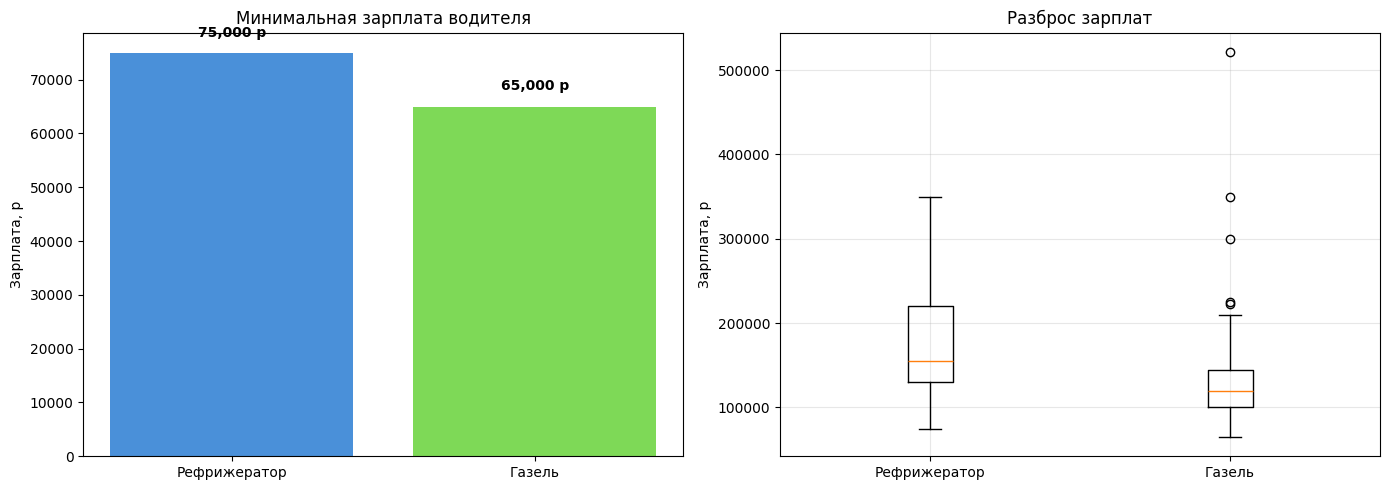

In [41]:
import matplotlib.pyplot as plt

ref_clean = refrigerator.df.dropna(subset=["salary_avg"])
ref_clean = ref_clean[ref_clean["salary_avg"] >= 50000]

gaz_clean = gazel.df.dropna(subset=["salary_avg"])
gaz_clean = gaz_clean[gaz_clean["salary_avg"] >= 50000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

professions = ["Рефрижератор", "Газель"]
min_salaries = [ref_clean["salary_avg"].min(), gaz_clean["salary_avg"].min()]

bars = axes[0].bar(professions, min_salaries, color=["#4A90D9", "#7ED957"])
axes[0].set_title("Минимальная зарплата водителя")
axes[0].set_ylabel("Зарплата, р")

for bar, value in zip(bars, min_salaries):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f"{value:,.0f} р",
        ha="center",
        fontweight="bold",
    )

axes[1].boxplot(
    [ref_clean["salary_avg"], gaz_clean["salary_avg"]],
    labels=professions,
)
axes[1].set_title("Разброс зарплат")
axes[1].set_ylabel("Зарплата, р")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

В любом случае слишком дорого, не берем водителя.